In [13]:
!pip install lasio


[notice] A new release of pip is available: 25.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


File found at: C:\Users\VASUNDHARA\Downloads\LAS_files_Force_2020_all_wells_train_test_blind_hidden_final\Force_2020_all_wells_train_test_blind_hidden_final\7_1-1.las
Available logs: Index(['FORCE_2020_LITHOFACIES_CONFIDENCE', 'FORCE_2020_LITHOFACIES_LITHOLOGY',
       'CALI', 'BS', 'DCAL', 'MUDWEIGHT', 'ROP', 'RDEP', 'RSHA', 'RMED', 'SP',
       'DTC', 'NPHI', 'GR', 'RHOB', 'DRHO', 'DEPTH_MD', 'X_LOC', 'Y_LOC',
       'Z_LOC'],
      dtype='object')


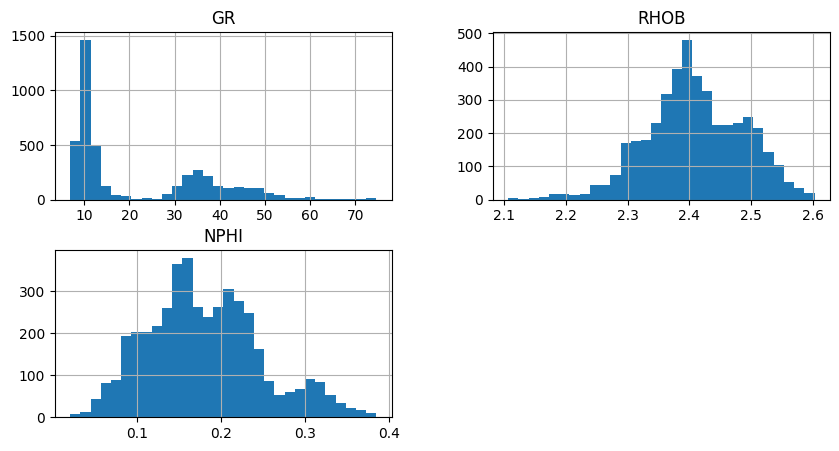

In [14]:
import lasio
import pandas as pd
import matplotlib.pyplot as plt
import os

# Define the folder to search
search_folder = r"C:\Users\VASUNDHARA\Downloads"
target_file = "7_1-1.las"

# Search for the file
found_path = None
for root, dirs, files in os.walk(search_folder):
    if target_file in files:
        found_path = os.path.join(root, target_file)
        break

if found_path:
    print(f"File found at: {found_path}")
    las = lasio.read(found_path)
    df = las.df()
    print("Available logs:", df.columns)
    df[['GR', 'RHOB', 'NPHI']].dropna().hist(bins=30, figsize=(10, 5))
    plt.show()
else:
    print("Could not find the file. Please check the filename in your folder.")

In [15]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import joblib

# 1. Create a label based on the rules
# We set a temporary competency_label column
# Low (0) = weak, High (1) = strong
df['competency_label'] = 0.5 # Default middle value

# Assigning labels based on your geological rules
# Weak: GR > 75 and NPHI is high
df.loc[(df['GR'] > 75) & (df['NPHI'] > 0.3), 'competency_label'] = 0.0 

# Strong: GR < 40 and RHOB is high and NPHI is low
df.loc[(df['GR'] < 40) & (df['RHOB'] > 2.5) & (df['NPHI'] < 0.1), 'competency_label'] = 1.0

# 2. Prepare data for the model
# Features (inputs) and Target (what we want to predict)
features = ['GR', 'RHOB', 'NPHI']
target = 'competency_label'

# Drop rows with empty values to avoid errors
data_clean = df[features + [target]].dropna()

X = data_clean[features]
y = data_clean[target]

# 3. Train the Model
# The Random Forest learns the patterns we just defined
model = RandomForestRegressor(n_estimators=100)
model.fit(X, y)

# 4. Save the model so you can use it later
# This creates the 'competency_model.pkl' file in your folder
joblib.dump(model, 'competency_model.pkl')

print("Model trained and saved as competency_model.pkl!")

Model trained and saved as competency_model.pkl!


"Rocks were classified as low-competency (weak) if GR > 75 and NPHI > 0.3. Rocks were classified as high-competency (strong) if GR < 40, RHOB > 2.5, and NPHI < 0.1."

In [16]:
import os
# This will print the location of your file
print("The file should be here:", os.path.abspath("competency_model.pkl"))

The file should be here: C:\Users\VASUNDHARA\competency_model.pkl


In [17]:
import os
import joblib

# 1. Define the exact path to your project's outputs folder
# We use an 'r' before the string to make sure Windows handles the path correctly
target_folder = r"C:\Users\VASUNDHARA\Desktop\geosentinel-plus\output"
target_file = os.path.join(target_folder, "competency_model.pkl")

# 2. Make sure the folder exists
if not os.path.exists(target_folder):
    os.makedirs(target_folder)
    print(f"Created folder: {target_folder}")

# 3. Save the model here
# Assuming your trained model variable is named 'model'
# If you get a 'NameError', run your training cell first!
joblib.dump(model, target_file)

print(f"Successfully saved model to: {target_file}")

Successfully saved model to: C:\Users\VASUNDHARA\Desktop\geosentinel-plus\output\competency_model.pkl


In [18]:
import os
import joblib

# This path tells Python to look inside the 'outputs' folder
model_path = os.path.join("outputs", "competency_model.pkl")

# To save:
joblib.dump(model, model_path)

# To load:
model = joblib.load(model_path)